In [1]:
import time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import joblib
import os
# import json


2025-09-19 17:21:43.141100: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-19 17:21:43.194547: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-19 17:21:44.147106: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Load and preprocess data
df = pd.read_csv('data.csv')
x = np.array(df.iloc[:, :2])
y = np.array(df.iloc[:, 2])

scaler_x = StandardScaler()
x = scaler_x.fit_transform(x)

scaler_y = StandardScaler()
y = y.reshape(-1, 1)  # Reshape y to have one feature
y = scaler_y.fit_transform(y)

x = torch.from_numpy(x).type(torch.FloatTensor)
y = torch.from_numpy(y).type(torch.FloatTensor)

# Split data into train, validation, and test sets
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=666)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=666)

train_dataset = torch.utils.data.TensorDataset(x_train, y_train)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=512, shuffle=True)

val_dataset = torch.utils.data.TensorDataset(x_val, y_val)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=512)

test_dataset = torch.utils.data.TensorDataset(x_test, y_test)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=512)


In [3]:
# Define the RNN model
class Net(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers, output=1):
        super(Net, self).__init__()
        self.hidden_dim = hidden_dim
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, output)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.linear(out)
        return out

# Instantiate the model
model = Net(hidden_dim=220, input_size=1, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.MSELoss()


In [4]:
# Training the model
train_loss_list = []
val_loss_list = []
train_mae_list = []
val_mae_list = []
for epoch in range(250):
    model.train()
    train_loss = 0
    train_mae = 0
    for batch_idx, (data, label) in enumerate(train_loader):
        data = data.reshape(-1, 2, 1)
        outputs = model(data)
        loss = criterion(outputs, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_mae += mean_absolute_error(label.detach().numpy(), outputs.detach().numpy())
    train_loss /= len(train_loader)
    train_mae /= len(train_loader)
    train_loss_list.append(train_loss)
    train_mae_list.append(train_mae)
    
    # Validation
    model.eval()
    val_loss = 0
    val_mae = 0
    with torch.no_grad():
        for batch_idx, (data, label) in enumerate(val_loader):
            data = data.reshape(-1, 2, 1)
            outputs = model(data)
            loss = criterion(outputs, label)
            val_loss += loss.item()
            val_mae += mean_absolute_error(label.detach().numpy(), outputs.detach().numpy())
    val_loss /= len(val_loader)
    val_mae /= len(val_loader)
    val_loss_list.append(val_loss)
    val_mae_list.append(val_mae)
    
    print(f'Epoch: {epoch+1}, Train Loss: {train_loss:.8f}, Val Loss: {val_loss:.8f}, Train MAE: {train_mae:.8f}, Val MAE: {val_mae:.8f}')
    

Epoch: 1, Train Loss: 0.63025475, Val Loss: 0.49898196, Train MAE: 0.66181865, Val MAE: 0.59139446
Epoch: 2, Train Loss: 0.49275909, Val Loss: 0.49250727, Train MAE: 0.58554393, Val MAE: 0.58231184
Epoch: 3, Train Loss: 0.48349870, Val Loss: 0.47509713, Train MAE: 0.58015463, Val MAE: 0.57281128
Epoch: 4, Train Loss: 0.44220598, Val Loss: 0.39435453, Train MAE: 0.55400380, Val MAE: 0.52192322
Epoch: 5, Train Loss: 0.29921744, Val Loss: 0.19322610, Train MAE: 0.44910619, Val MAE: 0.35965427
Epoch: 6, Train Loss: 0.12871224, Val Loss: 0.09026372, Train MAE: 0.27751594, Val MAE: 0.22848398
Epoch: 7, Train Loss: 0.08717832, Val Loss: 0.08058624, Train MAE: 0.21571610, Val MAE: 0.21035297
Epoch: 8, Train Loss: 0.08214878, Val Loss: 0.07781319, Train MAE: 0.20567187, Val MAE: 0.20352866
Epoch: 9, Train Loss: 0.08075327, Val Loss: 0.07654775, Train MAE: 0.20228036, Val MAE: 0.20319572
Epoch: 10, Train Loss: 0.07946906, Val Loss: 0.07738087, Train MAE: 0.19971699, Val MAE: 0.19994631
Epoch: 11

In [20]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, 'rnnmodel.pth')

print("Model saved successfully to 'rnnmodel.pth'")

Model saved successfully to 'rnnmodel.pth'


In [20]:
# 保存模型和训练历史
model_path = './rnnmodel/model_rnn_weight.pth'
os.makedirs(os.path.dirname(model_path), exist_ok=True)
torch.save(model.state_dict(), model_path)
print("Model saved to disk.")


Model saved to disk.


In [ ]:
# 保存训练历史
history = {
    'train_loss': train_loss_list,
    'val_loss': val_loss_list,
    'train_mae': train_mae_list,
    'val_mae': val_mae_list
}
history_path = './model/rnn_training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f)
print("Training history saved to disk.")


Training history saved to disk.


In [4]:
# Load the model
model_path = './rnnmodel/model_rnn_weight.pth'
model = Net(hidden_dim=220, input_size=1, num_layers=2)
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print("Model loaded from disk.")
else:
    print("Model file not found.")
    

Model loaded from disk.


In [5]:
# Testing the model
model.eval()
test_loss = 0
output = torch.zeros(size=(1, 1))
with torch.no_grad():
    for batch_idx, (data, label) in enumerate(test_loader):
        data = data.reshape(-1, 2, 1)
        outputs = model(data)
        output = torch.cat((output, outputs), 0)
        loss = criterion(outputs, label)
        test_loss += loss.item()

test_loss /= len(test_loader)
print(f'Test MSE: {test_loss:.8f}')

# Remove the initial zero
output = output[1:]

# Inverse transform
output = output.numpy()
y_test = y_test.numpy()
output = scaler_y.inverse_transform(output)
y_test = scaler_y.inverse_transform(y_test)

# Calculate Metrics
mse = mean_squared_error(y_test, output)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, output)
r2 = r2_score(y_test, output)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R² Score: {r2}")


Test MSE: 0.06919063
Mean Squared Error (MSE): 13.895088195800781
Root Mean Squared Error (RMSE): 3.727611541748047
Mean Absolute Error (MAE): 2.640897750854492
R² Score: 0.9302578070073911


损失图已保存到: rnn_fig/rnn_loss_plot.png
局部放大损失图已保存到: rnn_fig/zoom_loss_plot.png


/tmp/ipykernel_85398/1508963212.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


结合图已保存到: rnn_fig/rnn_combined_plot.png


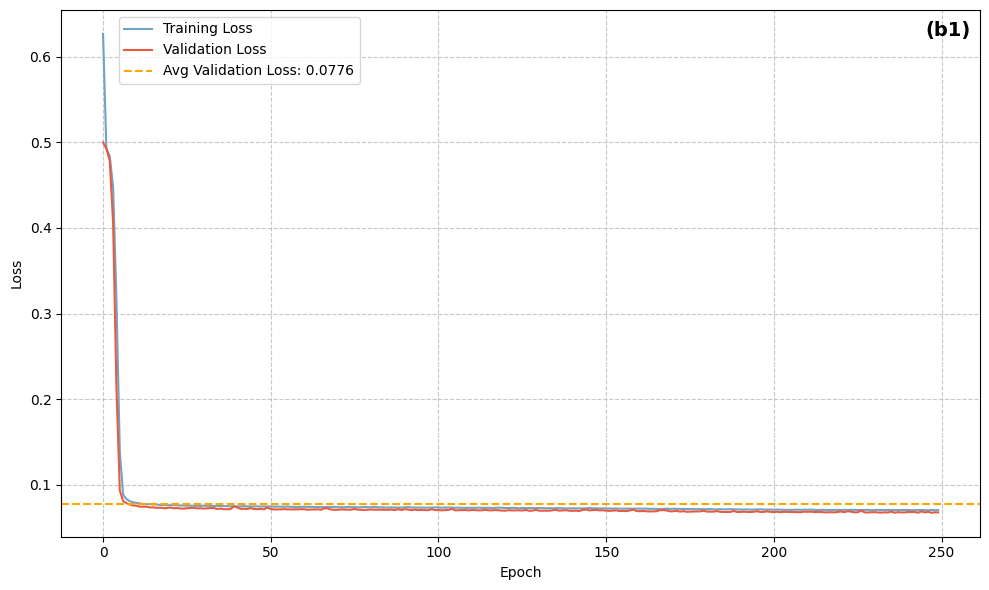

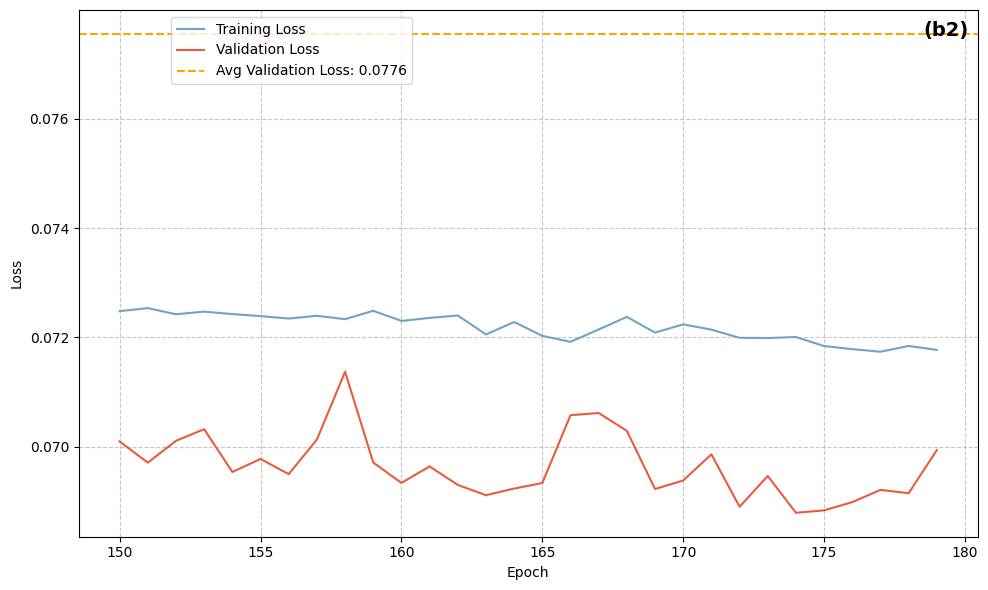

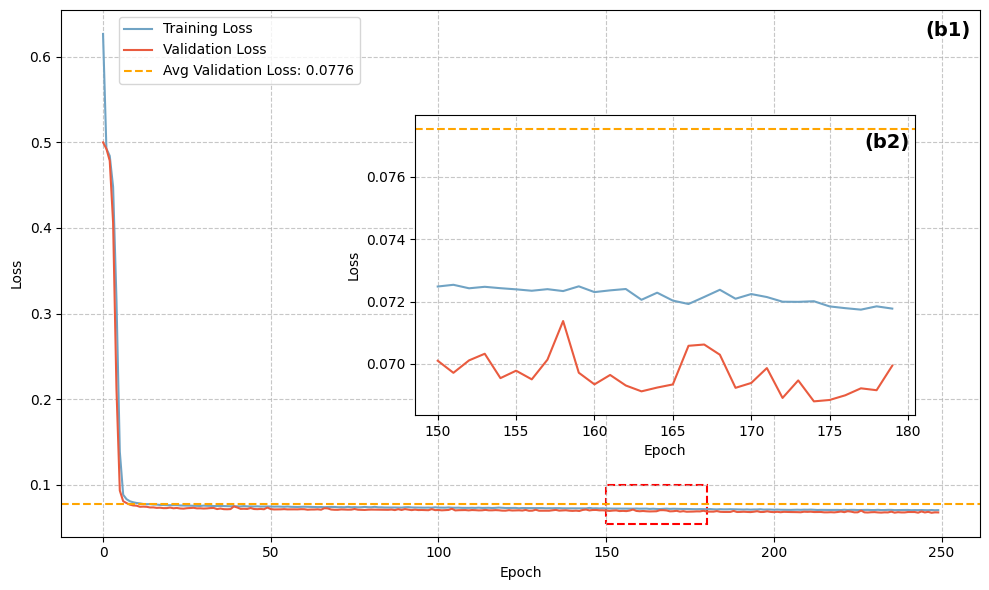

In [19]:
# 获取训练和验证 MAE
train_mae_list = train_mae_list  # 假设这些列表已经定义
val_mae_list = val_mae_list

# 获取训练和验证损失
train_loss_list = train_loss_list
val_loss_list = val_loss_list

# 计算平均验证损失和MAE
avg_val_loss = np.mean(val_loss_list)
avg_val_mae = np.mean(val_mae_list)

# 自定义放大区间
zoom_epoch_start = 150  # 自定义起始 epoch
zoom_epoch_end = 180    # 自定义结束 epoch

# 自定义虚线框高度
rect_y_min = 0.055  # 自定义虚线框的下边界
rect_y_max = 0.1 # 自定义虚线框的上边界

# 创建保存图片的文件夹
folder_name = "rnn_fig"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# 绘制损失图
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(train_loss_list, color='#70A3C4', label='Training Loss')
ax1.plot(val_loss_list, color='#E95B3F', label='Validation Loss')
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(b1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
loss_file_path = os.path.join(folder_name, 'rnn_loss_plot.png')
plt.savefig(loss_file_path, dpi=300, bbox_inches='tight')
print(f"损失图已保存到: {loss_file_path}")

# 绘制局部放大图
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss_list[zoom_epoch_start:zoom_epoch_end], color='#70A3C4', label='Training Loss')
ax2.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss_list[zoom_epoch_start:zoom_epoch_end], color='#E95B3F', label='Validation Loss')
ax2.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax2.legend(loc='upper left', bbox_to_anchor=(0.095, 1), bbox_transform=ax2.transAxes)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.text(0.99, 0.98, '(b2)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
zoom_loss_file_path = os.path.join(folder_name, 'zoom_loss_plot.png')
plt.savefig(zoom_loss_file_path, dpi=300, bbox_inches='tight')
print(f"局部放大损失图已保存到: {zoom_loss_file_path}")

# 绘制结合图，将局部放大图嵌入到主图中
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(train_loss_list, color='#70A3C4', label='Training Loss')
ax1.plot(val_loss_list, color='#E95B3F', label='Validation Loss')
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(b1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 嵌入放大损失图
inset_ax = fig.add_axes([0.42, 0.30, 0.5, 0.5])  # [left, bottom, width, height]
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss_list[zoom_epoch_start:zoom_epoch_end], color='#70A3C4')
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss_list[zoom_epoch_start:zoom_epoch_end], color='#E95B3F')
inset_ax.axhline(y=avg_val_loss, color='#FFA500', linestyle='--')  # 添加平均值线
inset_ax.set_xlabel('Epoch')
inset_ax.set_ylabel('Loss')
inset_ax.grid(True, linestyle='--', alpha=0.7)
inset_ax.text(0.99, 0.94, '(b2)', transform=inset_ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 添加红色虚线框
rect = plt.Rectangle((zoom_epoch_start, rect_y_min), 
                     zoom_epoch_end - zoom_epoch_start, 
                     rect_y_max - rect_y_min, 
                     edgecolor='red', linestyle='--', linewidth=1.5, facecolor='none', transform=ax1.transData)
ax1.add_patch(rect)

# 添加标注和链接
ax1.annotate('', xy=(0.6, 0.45), xycoords='axes fraction', xytext=(0.45, 0.25), textcoords='axes fraction',
             arrowprops=dict(facecolor='black', shrink=0.05, width=2))

plt.tight_layout()
combined_file_path = os.path.join(folder_name, 'rnn_combined_plot.png')
plt.savefig(combined_file_path, dpi=300, bbox_inches='tight')
print(f"结合图已保存到: {combined_file_path}")

# 显示图表
plt.show()

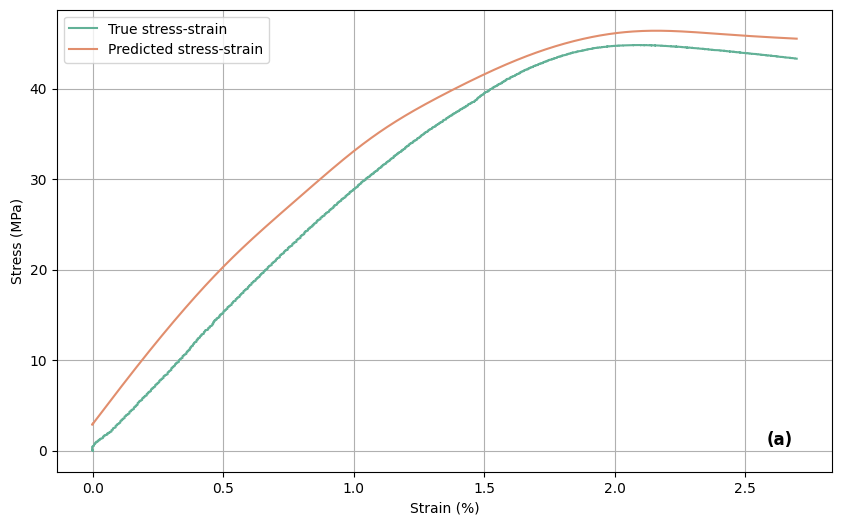

应力-应变曲线已保存并显示: rnn_fig/prediction/stress_strain_curve_angle_group_5.png


In [7]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

# 确保保存图片的文件夹存在
folder_path = os.path.join('rnn_fig', 'prediction')
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 读取新数据
file_name = 'Angle_group_5.csv'
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_x.transform(x_new)

# 转换为张量
x_new_tensor = torch.from_numpy(x_new_scaled).type(torch.FloatTensor).reshape(-1, 2, 1)

# 加载模型
model = Net(hidden_dim=220, input_size=1, num_layers=2)
model.load_state_dict(torch.load('./rnnmodel/model_rnn_weight.pth'))
model.eval()

# 进行预测
with torch.no_grad():
    stress_pred_scaled = model(x_new_tensor)

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_y.inverse_transform(stress_pred_scaled.numpy()).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 使用特定的应变阈值
strain_threshold = 2.7  # 根据之前的阈值设置
valid_indices = strain_truncated < strain_threshold
strain_truncated = strain_truncated[valid_indices]
stress_true_truncated = stress_true_truncated[valid_indices]
stress_pred_truncated = stress_pred_truncated[valid_indices]

# 绘制预测结果与真实值的对比图
plt.figure(figsize=(10, 6))
plt.plot(strain_truncated, stress_true_truncated, label='True stress-strain', color='#62B197')
plt.plot(strain_truncated, stress_pred_truncated, label='Predicted stress-strain', color='#E18E6D')
plt.xlabel('Strain (%)')
plt.ylabel('Stress (MPa)')
plt.legend()
# plt.title('True vs Predicted Stress-Strain Curve (Angle Group 5)')
plt.grid(True)
# 在右下角添加文本 (b1)
plt.text(0.95, 0.05, '(a)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')
# 保存图像
save_path = os.path.join(folder_path, 'stress_strain_curve_angle_group_5.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

# 关闭当前图形以释放内存
plt.close()

print(f"应力-应变曲线已保存并显示: {save_path}")

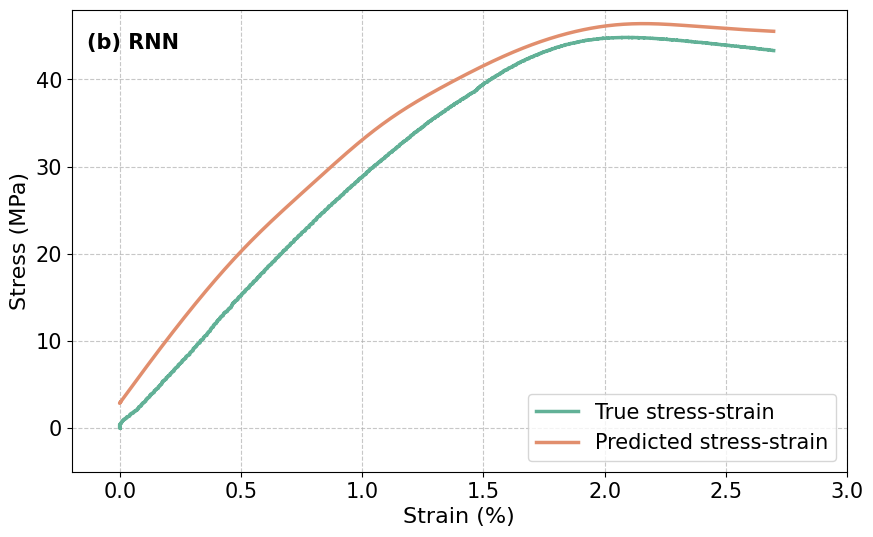

应力-应变曲线已保存并显示: rnn_fig/prediction/stress_strain_curve_angle_group_5.png


In [15]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

# 确保保存图片的文件夹存在
folder_path = os.path.join('rnn_fig', 'prediction')
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 读取新数据
file_name = 'Angle_group_5.csv'
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_x.transform(x_new)

# 转换为张量
x_new_tensor = torch.from_numpy(x_new_scaled).type(torch.FloatTensor).reshape(-1, 2, 1)

# 加载模型
model = Net(hidden_dim=220, input_size=1, num_layers=2)
model.load_state_dict(torch.load('./rnnmodel/model_rnn_weight.pth'))
model.eval()

# 进行预测
with torch.no_grad():
    stress_pred_scaled = model(x_new_tensor)

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_y.inverse_transform(stress_pred_scaled.numpy()).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 使用特定的应变阈值
strain_threshold = 2.7  # 根据之前的阈值设置
valid_indices = strain_truncated < strain_threshold
strain_truncated = strain_truncated[valid_indices]
stress_true_truncated = stress_true_truncated[valid_indices]
stress_pred_truncated = stress_pred_truncated[valid_indices]

# 绘制预测结果与真实值的对比图
# 绘制预测结果与真实值的对比图（仅调整样式与角标位置）
plt.figure(figsize=(10, 6))
plt.plot(strain_truncated, stress_true_truncated,
         label='True stress-strain', color='#62B197', linewidth=2.5)
plt.plot(strain_truncated, stress_pred_truncated,
         label='Predicted stress-strain', color='#E18E6D', linewidth=2.5)

# 坐标轴与刻度字号（不改变原有刻度，只放大字体）
plt.xlabel('Strain (%)', fontsize=16)
plt.ylabel('Stress (MPa)', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(-0.2, 3)
plt.ylim(-5, 48)

# 图例与网格（图例固定右下角）
plt.legend(fontsize=15, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 角标：移到左上角，并标明模型
plt.text(0.02, 0.95, '(b) RNN', transform=plt.gca().transAxes,
         fontsize=15, fontweight='bold', ha='left', va='top')

# 保存图像
save_path = os.path.join(folder_path, 'stress_strain_curve_angle_group_5.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 显示并关闭
plt.show()
plt.close()

print(f"应力-应变曲线已保存并显示: {save_path}")


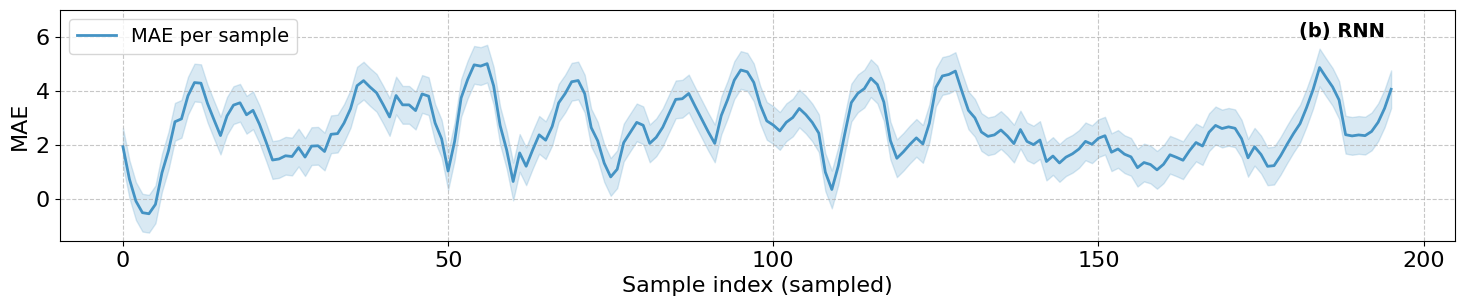

MAE per sample plot saved and displayed: ./rnn_fig/mae_per_sample.png


In [7]:
from scipy.signal import savgol_filter
from matplotlib.ticker import MultipleLocator

from scipy.signal import savgol_filter
# 计算每个样本的 MAE
mae_per_sample = np.abs(y_test - output).flatten()

# 采样数据以减少密度（例如，每隔250个点取一个）
sampling_rate =80
mae_sampled = mae_per_sample[::sampling_rate]

# 确保 window_length 小于或等于数据长度，并且是奇数
window_length = min(11, len(mae_sampled))
if window_length % 2 == 0:
    window_length -= 1

# 如果 window_length 仍然大于数据长度，调整为数据长度的最大奇数
if window_length < 3:
    window_length = 3

# 平滑曲线（使用 Savitzky-Golay 滤波器）
polyorder = 2  # 确保 polyorder 小于 window_length
mae_smoothed = savgol_filter(mae_sampled, window_length, polyorder)

# 绘制 MAE 随时间变化的图
plt.figure(figsize=(18, 3))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(mae_smoothed, label='MAE per sample', color='#4493C4', linewidth=2)

# 添加跟随曲线变化的窄色条
offset = 0.7  # 设置窄色条的宽度
plt.fill_between(range(len(mae_smoothed)), mae_smoothed - offset, mae_smoothed + offset, color='#4493C4', alpha=0.2)

# 设置图例位置为左上角
plt.legend(loc='upper left', fontsize=14)

# 在右上角添加文本 (a)
plt.text(0.95, 0.95, '(b) RNN', fontsize=14, fontweight='bold', ha='right', va='top', transform=plt.gca().transAxes)

plt.xlabel('Sample index (sampled)', fontsize=16)
plt.ylabel('MAE', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(50))

# 调整 y 轴范围以增加图例和曲线之间的距离
plt.ylim(bottom=min(mae_smoothed) - 1, top=max(mae_smoothed) + 2)

# 保存图像
mae_timestep_path = './rnn_fig/mae_per_sample.png'
plt.savefig(mae_timestep_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

# 关闭当前图形以释放内存
plt.close()

print(f"MAE per sample plot saved and displayed: {mae_timestep_path}")

RNN模型在完整数据集上的误差计算完成。


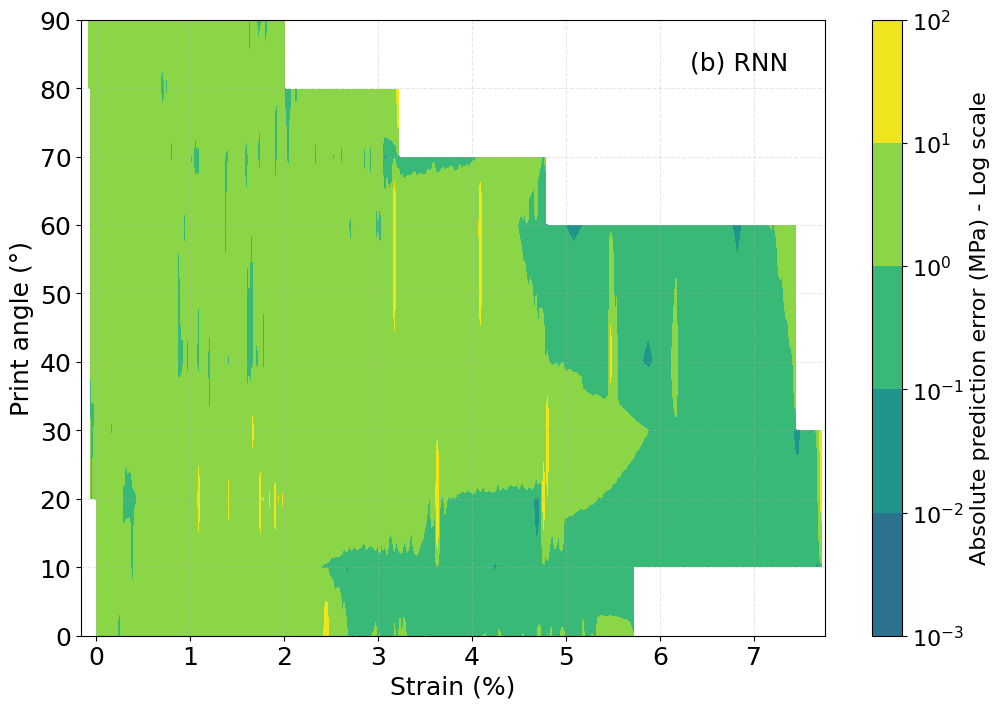


RNN模型的误差等高线图已保存至: ./rnn_fig/rnn_error_contour_log_scale.png


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn

# --- 假设您RNN.ipynb中的模型定义和数据加载逻辑可用 ---

# 步骤 1: 加载完整数据集并准备归一化工具
df_full = pd.read_csv('data.csv')
df_full.drop_duplicates(inplace=True)

# 按照正确的顺序定义特征和目标
x_full = df_full.iloc[:, :2].values  # 第一列角度, 第二列应变
y_full_true_original = df_full.iloc[:, 2].values

# 创建并拟合归一化工具
scaler_x = StandardScaler().fit(x_full)
scaler_y = StandardScaler().fit(y_full_true_original.reshape(-1, 1))

# 步骤 2: 定义并加载您训练好的PyTorch RNN模型
class Net(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers, output=1):
        super(Net, self).__init__()
        self.hidden_dim = hidden_dim
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, output)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.linear(out)
        return out

# 实例化模型并加载权重
model_rnn = Net(hidden_dim=220, input_size=1, num_layers=2)
model_rnn.load_state_dict(torch.load('./rnnmodel/model_rnn_weight.pth'))
model_rnn.eval() # 设置为评估模式

# 步骤 3: 在完整数据集上进行预测并计算误差
# 归一化输入特征
x_full_scaled = scaler_x.transform(x_full)
# 转换为PyTorch张量并调整形状以适应RNN输入
x_full_tensor = torch.from_numpy(x_full_scaled).type(torch.FloatTensor).reshape(-1, 2, 1)

# 进行预测
with torch.no_grad():
    y_full_pred_scaled = model_rnn(x_full_tensor)

# 反归一化预测结果
y_full_pred_original = scaler_y.inverse_transform(y_full_pred_scaled.numpy())
absolute_error = np.abs(y_full_pred_original.flatten() - y_full_true_original.flatten())

# 创建用于绘图的DataFrame
df_plot = pd.DataFrame({
    'Strain': x_full[:, 1],  # 第二列是应变
    'Angle': x_full[:, 0],   # 第一列是角度
    'Error': absolute_error
})
print("RNN模型在完整数据集上的误差计算完成。")

# --- 步骤 4: 使用分步式插值和对数色阶绘图 (与ANN图的逻辑完全相同) ---
df_plot['Angle_Group'] = df_plot['Angle'].round(0)
unique_angles = sorted(df_plot['Angle_Group'].unique())

grid_resolution = 400
strain_common = np.linspace(df_plot['Strain'].min(), df_plot['Strain'].max(), grid_resolution)
angle_grid_dense = np.linspace(df_plot['Angle'].min(), df_plot['Angle'].max(), grid_resolution)

aligned_errors = {}
for ang in unique_angles:
    group = df_plot[df_plot['Angle_Group'] == ang].sort_values('Strain')
    if len(group) > 1:
        interp_func = interp1d(group['Strain'], group['Error'], bounds_error=False, fill_value=np.nan)
        aligned_errors[ang] = interp_func(strain_common)

final_grid_error = np.zeros((len(angle_grid_dense), len(strain_common)))
for i, s in enumerate(strain_common):
    current_errors = [aligned_errors[ang][i] for ang in unique_angles if ang in aligned_errors]
    valid_angles = [ang for ang in unique_angles if ang in aligned_errors]
    valid_indices = ~np.isnan(current_errors)
    if np.sum(valid_indices) > 1:
        interp_func_angle = interp1d(
            np.array(valid_angles)[valid_indices],
            np.array(current_errors)[valid_indices],
            bounds_error=False,
            fill_value=np.nan
        )
        final_grid_error[:, i] = interp_func_angle(angle_grid_dense)
    else:
        final_grid_error[:, i] = np.nan

# 绘制最终图表
target_strain, target_angle = np.meshgrid(strain_common, angle_grid_dense)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 8))
final_grid_error_masked = np.ma.masked_invalid(final_grid_error)

# 使用对数归一化 (LogNorm)
min_error_for_log = df_plot['Error'][df_plot['Error'] > 0].min()
norm = mcolors.LogNorm(vmin=min_error_for_log, vmax=df_plot['Error'].max())

contour = ax.contourf(target_strain, target_angle, final_grid_error_masked, levels=100, cmap='viridis', norm=norm)

# 格式化图表
cbar = fig.colorbar(contour)
cbar.set_label('Absolute prediction error (MPa) - Log scale', fontsize=16)
cbar.ax.tick_params(labelsize=16)
ax.set_xlabel('Strain (%)', fontsize=18)
ax.set_ylabel('Print angle (°)', fontsize=18)
ax.grid(True, linestyle='--', alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=18)

# 添加子图标签
ax.text(0.95, 0.95, '(b) RNN', 
        transform=ax.transAxes, 
        fontsize=18, 
        ha='right', 
        va='top')

# 保存图像
final_plot_path = './rnn_fig/rnn_error_contour_log_scale.png'
plt.savefig(final_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nRNN模型的误差等高线图已保存至: {final_plot_path}")

In [7]:
# 计算并保存 df_plot 与重采样网格（noTL_docs/rnn）——最小改动，不改绘图
import os
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import interp1d

# 1) 在全数据上生成 df_plot（加载权重并用标准化预测）
df_full = pd.read_csv('data.csv')
df_full.drop_duplicates(inplace=True)

# 第一列 Angle，第二列 Strain，第三列真实应力
x_full = df_full.iloc[:, :2].values
y_full_true_original = df_full.iloc[:, 2].values

# 归一化器（与本笔记本其他单元一致，直接基于全量数据拟合）
scaler_x_full = StandardScaler().fit(x_full)
scaler_y_full = StandardScaler().fit(y_full_true_original.reshape(-1, 1))

# RNN 模型结构需与训练时一致
class Net(torch.nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers, output=1):
        super(Net, self).__init__()
        self.hidden_dim = hidden_dim
        self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.linear = torch.nn.Linear(hidden_dim, output)
    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.linear(out)
        return out

model_rnn = Net(hidden_dim=220, input_size=1, num_layers=2)
model_rnn.load_state_dict(torch.load('./rnnmodel/model_rnn_weight.pth'))
model_rnn.eval()

x_full_scaled = scaler_x_full.transform(x_full)
x_full_tensor = torch.from_numpy(x_full_scaled).type(torch.FloatTensor).reshape(-1, 2, 1)
with torch.no_grad():
    y_full_pred_scaled = model_rnn(x_full_tensor)

y_full_pred_original = scaler_y_full.inverse_transform(y_full_pred_scaled.numpy())
absolute_error = np.abs(y_full_pred_original.flatten() - y_full_true_original.flatten())

# 构造并保存 df_plot
df_plot = pd.DataFrame({'Strain': x_full[:, 1], 'Angle': x_full[:, 0], 'Error': absolute_error})
out_dir = './noTL_docs/rnn'
os.makedirs(out_dir, exist_ok=True)
df_plot.to_csv(os.path.join(out_dir, 'df_plot.csv'), index=False)

# 2) 分步式插值生成重采样网格，并保存为 npy/npz
grid_resolution = 400
strain_common = np.linspace(df_plot['Strain'].min(), df_plot['Strain'].max(), grid_resolution)
angle_grid_dense = np.linspace(df_plot['Angle'].min(), df_plot['Angle'].max(), grid_resolution)

# 按角度分组后，沿应变方向插值对齐
df_plot['Angle_Group'] = df_plot['Angle'].round(0)
unique_angles = sorted(df_plot['Angle_Group'].unique())
aligned_errors = {}
for ang in unique_angles:
    group = df_plot[df_plot['Angle_Group'] == ang].sort_values('Strain')
    if len(group) > 1:
        f = interp1d(group['Strain'], group['Error'], bounds_error=False, fill_value=np.nan)
        aligned_errors[ang] = f(strain_common)

# 沿角度方向插值，得到最终二维误差网格
final_grid_error = np.zeros((len(angle_grid_dense), len(strain_common)))
for i in range(len(strain_common)):
    current_errors = [aligned_errors[ang][i] for ang in unique_angles if ang in aligned_errors]
    valid_angles = [ang for ang in unique_angles if ang in aligned_errors]
    current_errors = np.array(current_errors)
    valid_angles = np.array(valid_angles)
    valid_mask = ~np.isnan(current_errors)
    if np.sum(valid_mask) > 1:
        g = interp1d(valid_angles[valid_mask], current_errors[valid_mask], bounds_error=False, fill_value=np.nan)
        final_grid_error[:, i] = g(angle_grid_dense)
    else:
        final_grid_error[:, i] = np.nan

# 保存数组
np.save(os.path.join(out_dir, 'strain_common.npy'), strain_common)
np.save(os.path.join(out_dir, 'angle_grid_dense.npy'), angle_grid_dense)
np.save(os.path.join(out_dir, 'final_grid_error.npy'), final_grid_error)
np.savez(os.path.join(out_dir, 'rnn_grids.npz'),
         strain_common=strain_common,
         angle_grid_dense=angle_grid_dense,
         final_grid_error=final_grid_error)

print(f"RNN df_plot 与网格已保存至: {out_dir}")


RNN df_plot 与网格已保存至: ./noTL_docs/rnn


In [11]:
# 计算 Angle_group_5.csv 的 MAE / RMSE / R²（全量与 Strain<2.7）并保存
import os
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 目录确保
os.makedirs(os.path.join('rnn_fig', 'prediction'), exist_ok=True)

# 读取未见测试数据
file_name = 'Angle_group_5.csv'
df_new = pd.read_csv(file_name)

# 特征与目标（训练时特征为 [Angle, Strain]；目标为 Stress）
x_new = df_new.iloc[:, :2].values
strain = df_new.iloc[:, 1].values  # 第二列应变
stress_true = df_new.iloc[:, 2].values.reshape(-1, 1)  # 第三列真实应力

# 归一化输入
x_new_scaled = scaler_x.transform(x_new)

# 加载模型并预测（与训练结构一致）
model_eval = Net(hidden_dim=220, input_size=1, num_layers=2)
model_eval.load_state_dict(torch.load('./rnnmodel/model_rnn_weight.pth'))
model_eval.eval()

x_new_tensor = torch.from_numpy(x_new_scaled).type(torch.FloatTensor).reshape(-1, 2, 1)
with torch.no_grad():
    stress_pred_scaled = model_eval(x_new_tensor)

# 反归一化到原始量纲
stress_pred = scaler_y.inverse_transform(stress_pred_scaled.numpy())

# 对齐长度并扁平化
min_len = min(len(stress_true), len(stress_pred))
true_all = stress_true[:min_len].flatten()
pred_all = stress_pred[:min_len].flatten()
strain_all = strain[:min_len]

# 全量指标
mse_all = mean_squared_error(true_all, pred_all)
rmse_all = np.sqrt(mse_all)
mae_all = mean_absolute_error(true_all, pred_all)
r2_all = r2_score(true_all, pred_all)

# 阈值内（与绘图一致）：Strain < 2.7
strain_threshold = 2.7
mask = strain_all < strain_threshold
true_thr = true_all[mask]
pred_thr = pred_all[mask]

mse_thr = mean_squared_error(true_thr, pred_thr) if len(true_thr) > 0 else np.nan
rmse_thr = np.sqrt(mse_thr) if np.isfinite(mse_thr) else np.nan
mae_thr = mean_absolute_error(true_thr, pred_thr) if len(true_thr) > 0 else np.nan
r2_thr = r2_score(true_thr, pred_thr) if len(true_thr) > 1 else np.nan

# 打印结果
print('=== Angle_group_5.csv metrics (RNN) ===')
print(f'All samples   -> MAE={mae_all:.4f}, RMSE={rmse_all:.4f}, R²={r2_all:.4f}')
if np.isfinite(mae_thr):
    print(f'Strain<2.7   -> MAE={mae_thr:.4f}, RMSE={rmse_thr:.4f}, R²={r2_thr:.4f}')
else:
    print('Strain<2.7   -> 无有效样本')

# 保存至 CSV
metrics_df = pd.DataFrame([
    {'scope': 'all',        'MAE': mae_all, 'RMSE': rmse_all, 'R2': r2_all},
    {'scope': 'strain<2.7', 'MAE': mae_thr, 'RMSE': rmse_thr, 'R2': r2_thr},
])
metrics_path = os.path.join('rnn_fig', 'prediction', 'Angle_group_5_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'Metrics saved to: {metrics_path}')


=== Angle_group_5.csv metrics (RNN) ===
All samples   -> MAE=3.2060, RMSE=3.8278, R²=0.9238
Strain<2.7   -> MAE=3.1360, RMSE=3.4153, R²=0.9422
Metrics saved to: rnn_fig/prediction/Angle_group_5_metrics.csv


In [7]:
import os, numpy as np, pandas as pd, torch

STRAIN_MAX = 2.5  # 设为 None 则导出全量

# 读取测试集（Angle_group_5）
df = pd.read_csv('Angle_group_5.csv')
x_new = df.iloc[:, :2].values
strain = df.iloc[:, 1].values
stress_true = df.iloc[:, 2].values

# 确保 scaler 存在（优先复用当前会话的 scaler_x/scaler_y）
try:
    _ = scaler_x.mean_; _ = scaler_y.mean_
except Exception as e:
    raise RuntimeError('请先在当前会话中构建/加载 RNN 的 scaler_x/scaler_y') from e

# 确保模型存在（优先复用当前会话的 model；否则从磁盘加载权重）
try:
    model
except NameError:
    class Net(torch.nn.Module):
        def __init__(self, input_size, hidden_dim, num_layers, output=1):
            super(Net, self).__init__()
            self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
            self.linear = torch.nn.Linear(hidden_dim, output)
        def forward(self, x):
            out, _ = self.rnn(x)
            out = out[:, -1, :]
            return self.linear(out)
    model = Net(hidden_dim=220, input_size=1, num_layers=2)
    model.load_state_dict(torch.load('./rnnmodel/model_rnn_weight.pth'))
model.eval()

# 预测
x_scaled = scaler_x.transform(x_new)
x_tensor = torch.from_numpy(x_scaled).float().reshape(-1, 2, 1)
with torch.no_grad():
    y_pred_scaled = model(x_tensor).cpu().numpy()
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 残差与筛选
n = min(len(strain), len(y_pred), len(stress_true))
strain = strain[:n]
residual = y_pred[:n] - stress_true[:n]
if STRAIN_MAX is not None:
    mask = strain <= STRAIN_MAX
    strain, residual = strain[mask], residual[mask]

# 保存
out_dir = 'rnn_fig/prediction'; os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'residuals_RNN.csv')
pd.DataFrame({'strain': strain, 'residual': residual}).to_csv(out_path, index=False)
print('saved:', out_path)

saved: rnn_fig/prediction/residuals_RNN.csv
